In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_fscore_support,accuracy_score,confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib


In [47]:
df = pd.read_csv(r"D:\Predictive_deploy\model_ready.csv")
if 'is_productive' not in df.columns:
    raise ValueError('Target is_productive not found in model_ready.csv')
    

In [48]:
X = df.drop(columns=['is_productive','is_healthy'], errors='ignore')
y = df['is_productive']
y.value_counts()

is_productive
0    25205
1     4795
Name: count, dtype: int64

In [49]:
# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [50]:
# Option 1: No SMOTE (class_weight)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [51]:
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [52]:
probs = logreg.predict_proba(X_val_scaled)[:,1]
preds = (probs >= 0.5).astype(int)

In [53]:
auc = roc_auc_score(y_val, preds)
prec, rec, f1, _ = precision_recall_fscore_support(y_val, preds, average='binary')
metrics = {'model':'Logistic_noSMOTE','auc':auc,'precision':prec,'recall':rec,'f1':f1}




Model: Logistic Regression
Accuracy: 0.8253333333333334
              precision    recall  f1-score   support

           0       0.96      0.82      0.89      5041
           1       0.47      0.83      0.60       959

    accuracy                           0.83      6000
   macro avg       0.72      0.83      0.75      6000
weighted avg       0.88      0.83      0.84      6000



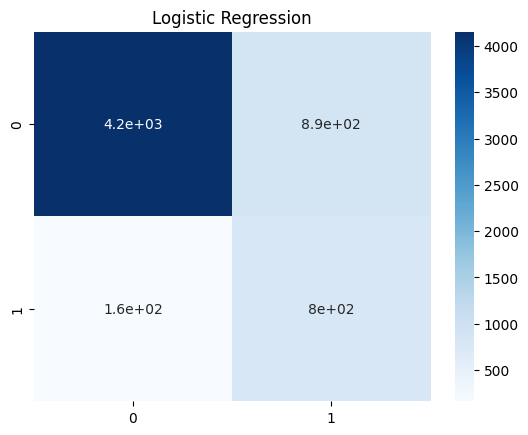

In [54]:
print(f"\nModel: Logistic Regression")
print("Accuracy:", accuracy_score(y_val,preds))
print(classification_report(y_val, preds))
sns.heatmap(confusion_matrix(y_val,preds), annot=True, cmap="Blues")
plt.title("Logistic Regression")
plt.show()

In [55]:
# Save scaler and model
joblib.dump(scaler, 'D:/Predictive_deploy/models/logreg_scaler.pkl')
joblib.dump(logreg, 'D:/Predictive_deploy/models/logreg_no_smote.pkl')

['D:/Predictive_deploy/models/logreg_no_smote.pkl']

In [56]:
# Append metrics
import os
import pandas as pd

# Create directory
results_path = r'D:\Predictive_deploy\results'
os.makedirs(results_path, exist_ok=True)

In [57]:
file_path = r'D:/Predictive_deploy\results\model_metrics.csv'
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(
    file_path,
    mode='a',
    header=not os.path.exists(file_path),
    index=False
)

In [58]:
# Option 2: With SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [59]:
scaler_sm = StandardScaler()
X_train_res_s = scaler_sm.fit_transform(X_train_res)
X_val_s = scaler_sm.transform(X_val)

In [60]:
logreg_sm = LogisticRegression(max_iter=1000, class_weight=None, random_state=42)
logreg_sm.fit(X_train_res_s, y_train_res)


LogisticRegression(max_iter=1000, random_state=42)

In [61]:
probs_sm = logreg_sm.predict_proba(X_val_s)[:,1]
preds_sm = (probs_sm >= 0.5).astype(int)

In [62]:
auc = roc_auc_score(y_val, preds_sm)
prec, rec, f1, _ = precision_recall_fscore_support(y_val, preds_sm, average='binary')
metrics_sm = {'model':'Logistic_SMOTE','auc':auc,'precision':prec,'recall':rec,'f1':f1}




Model: Logistic Regression(Smote)
Accuracy: 0.8548333333333333
              precision    recall  f1-score   support

           0       0.93      0.90      0.91      5041
           1       0.54      0.64      0.59       959

    accuracy                           0.85      6000
   macro avg       0.73      0.77      0.75      6000
weighted avg       0.87      0.85      0.86      6000



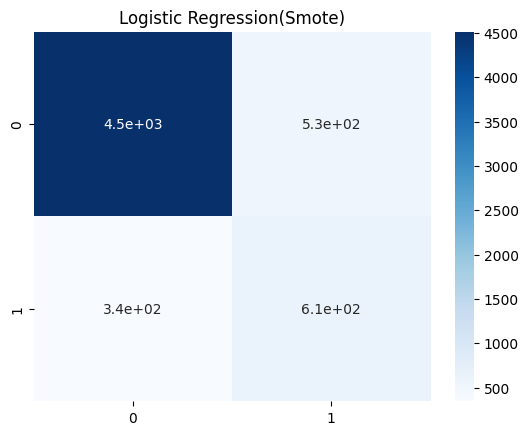

In [63]:
print(f"\nModel: Logistic Regression(Smote)")
print("Accuracy:", accuracy_score(y_val,preds_sm))
print(classification_report(y_val, preds_sm))
sns.heatmap(confusion_matrix(y_val,preds_sm), annot=True, cmap="Blues")
plt.title("Logistic Regression(Smote)")
plt.show()

In [64]:
models_path = r'D:\Predictive_deploy\models'
os.makedirs(models_path, exist_ok=True)
joblib.dump(scaler_sm, r'D:\Predictive_deploy\models\logreg_sm_scaler.pkl')
joblib.dump(logreg_sm, r'D:\Predictive_deploy\models\logreg_sm.pkl')

['D:\\Predictive_deploy\\models\\logreg_sm.pkl']

In [65]:
metrics_df2 = pd.DataFrame([metrics_sm])
metrics_df2.to_csv('D:/Predictive_deploy/results/model_metrics.csv', mode='a', header=False, index=False)